In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import minimize
from statsmodels.graphics.tsaplots import plot_acf
import math

import sys
sys.path.append('..')
from src.price_model import *
from src.optimization import *
from src.simulation import *

DATA_DIR = Path("../data")
ciso = pd.read_csv(DATA_DIR / "prices_CISO.csv")
nyiso = pd.read_csv(DATA_DIR / "prices_NYIS.csv")

# Parse datetime and extract components
ciso["hour"] = pd.to_datetime(ciso["hour"])
ciso["hour_of_day"] = ciso["hour"].dt.hour
ciso["dow"] = ciso["hour"].dt.dayofweek
ciso["month"] = ciso["hour"].dt.month

nyiso["hour"] = pd.to_datetime(nyiso["hour"])
nyiso["hour_of_day"] = nyiso["hour"].dt.hour
nyiso["dow"] = nyiso["hour"].dt.dayofweek
nyiso["month"] = nyiso["hour"].dt.month

In [2]:
ciso_results = walk_forward_backtest(ciso)
ciso_revenues = [r["revenue"] for r in ciso_results]

Week  1 | rev = $    15,477 | theta = 0.0213 |sigma=7.88
Week  2 | rev = $     8,939 | theta = 0.0178 |sigma=7.72
Week  3 | rev = $    14,247 | theta = 0.0206 |sigma=7.52
Week  4 | rev = $    20,923 | theta = 0.0198 |sigma=7.29
Week  5 | rev = $    18,553 | theta = 0.0190 |sigma=7.17
Week  6 | rev = $    16,142 | theta = 0.0160 |sigma=7.00
Week  7 | rev = $    10,114 | theta = 0.0123 |sigma=6.91
Week  8 | rev = $    18,535 | theta = 0.0137 |sigma=6.81
Week  9 | rev = $    24,222 | theta = 0.0203 |sigma=6.29
Week 10 | rev = $    23,219 | theta = 0.0177 |sigma=5.66
Week 11 | rev = $    19,130 | theta = 0.0086 |sigma=6.45
Week 12 | rev = $    22,710 | theta = 0.0153 |sigma=5.80
Week 13 | rev = $    19,275 | theta = 0.0167 |sigma=5.81
Week 14 | rev = $    23,898 | theta = 0.0157 |sigma=5.88
Week 15 | rev = $    16,047 | theta = 0.0152 |sigma=5.95
Week 16 | rev = $    16,447 | theta = 0.0105 |sigma=6.02
Week 17 | rev = $    16,290 | theta = 0.0110 |sigma=5.99
Week 18 | rev = $    15,943 | t

In [16]:
nyiso_results = walk_forward_backtest(nyiso)
nyiso_revenues = [r["revenue"] for r in nyiso_results]

Week  1 | rev = $     4,641 | theta = 0.0144 |sigma=2.52
Week  2 | rev = $     4,352 | theta = 0.0102 |sigma=2.57
Week  3 | rev = $     5,975 | theta = 0.0086 |sigma=2.68
Week  4 | rev = $     4,066 | theta = 0.0126 |sigma=2.81
Week  5 | rev = $     4,841 | theta = 0.0117 |sigma=3.14
Week  6 | rev = $     4,148 | theta = 0.0293 |sigma=2.81
Week  7 | rev = $     4,639 | theta = 0.0306 |sigma=2.78
Week  8 | rev = $     3,336 | theta = 0.0356 |sigma=2.73
Week  9 | rev = $     3,418 | theta = 0.0312 |sigma=2.78
Week 10 | rev = $     3,332 | theta = 0.0301 |sigma=2.77
Week 11 | rev = $     3,029 | theta = 0.0284 |sigma=2.78
Week 12 | rev = $     2,128 | theta = 0.0251 |sigma=2.77
Week 13 | rev = $     1,941 | theta = 0.0504 |sigma=2.20
Week 14 | rev = $     1,818 | theta = 0.0123 |sigma=2.57
Week 15 | rev = $     1,932 | theta = 0.0287 |sigma=2.18
Week 16 | rev = $       949 | theta = 0.0280 |sigma=2.15
Week 17 | rev = $       961 | theta = 0.0415 |sigma=1.94
Week 18 | rev = $     1,914 | t

In [17]:
#trimmed mean sharpe

ciso_sorted_rev = sorted(ciso_revenues)
ciso_trimmed = ciso_sorted_rev[5:-5]
print(f"CISO Trimmed mean: ${np.mean(ciso_trimmed):,.0f}")
print(f"CISO Trimmed Sharpe: {np.mean(ciso_trimmed) / np.std(ciso_trimmed):.2f}")


nyiso_sorted_rev = sorted(nyiso_revenues)
nyiso_trimmed = nyiso_sorted_rev[5:-5]
print(f"NYISO Trimmed mean: ${np.mean(nyiso_trimmed):,.0f}")
print(f"NYISO Trimmed Sharpe: {np.mean(nyiso_trimmed) / np.std(nyiso_trimmed):.2f}")

CISO Trimmed mean: $12,370
CISO Trimmed Sharpe: 1.64
NYISO Trimmed mean: $9,480
NYISO Trimmed Sharpe: 1.48


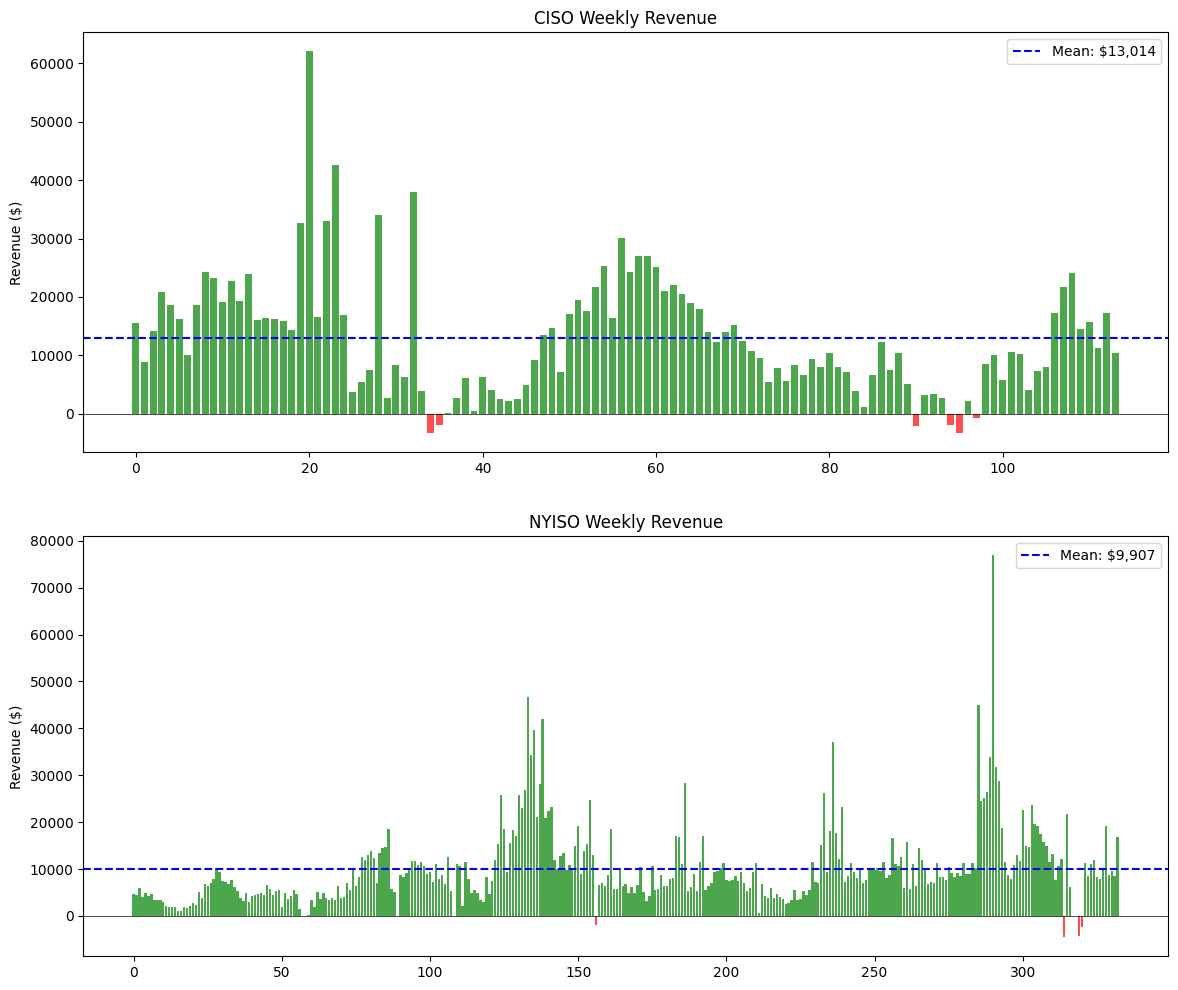

In [18]:
#weekly rev bar chart
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

axes[0].bar(range(len(ciso_revenues)), ciso_revenues, 
            color=['green' if r > 0 else 'red' for r in ciso_revenues], alpha=0.7)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].axhline(y=np.mean(ciso_revenues), color='blue', linestyle='--', 
                label=f'Mean: ${np.mean(ciso_revenues):,.0f}')
axes[0].set_ylabel("Revenue ($)")
axes[0].set_title("CISO Weekly Revenue")
axes[0].legend()

axes[1].bar(range(len(nyiso_revenues)), nyiso_revenues, 
            color=['green' if r > 0 else 'red' for r in nyiso_revenues], alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].axhline(y=np.mean(nyiso_revenues), color='blue', linestyle='--', 
                label=f'Mean: ${np.mean(nyiso_revenues):,.0f}')
axes[1].set_ylabel("Revenue ($)")
axes[1].set_title("NYISO Weekly Revenue")
axes[1].legend()

plt.show()

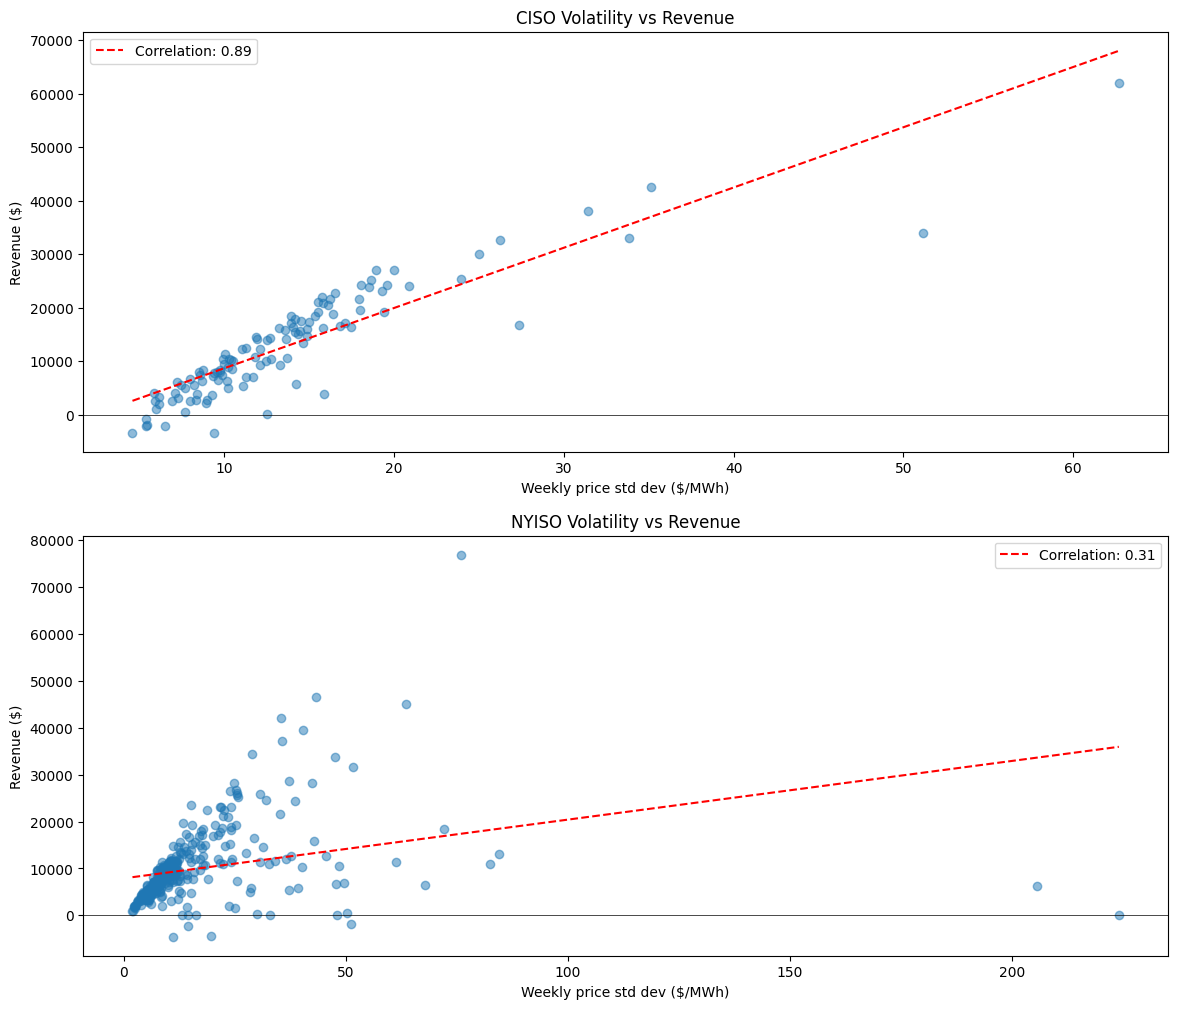

CISO Correlation (vol, rev): 0.89
NYISO Correlation (vol, rev): 0.31


In [22]:
#vol vs rev scatter w cor.
eval_window = 24 * 7

fig, axes = plt.subplots(2,1,figsize=(14,12))

ciso_vols = []
for r in ciso_results:
    start = r["eval_start"]
    week_prices = ciso["price_usd_mwh"].values[start:start + eval_window]
    r["volatility"] = np.std(week_prices)
    ciso_vols.append(r["volatility"])

axes[0].scatter(ciso_vols, ciso_revenues, alpha=0.5)
z = np.polyfit(ciso_vols, ciso_revenues, 1)
x_line = np.linspace(min(ciso_vols), max(ciso_vols), 100)
axes[0].plot(x_line, np.polyval(z, x_line), 'r--', 
             label=f'Correlation: {np.corrcoef(ciso_vols, ciso_revenues)[0,1]:.2f}')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_xlabel("Weekly price std dev ($/MWh)")
axes[0].set_ylabel("Revenue ($)")
axes[0].set_title("CISO Volatility vs Revenue")
axes[0].legend()


nyiso_vols = []
for r in nyiso_results:
    start = r["eval_start"]
    week_prices = nyiso["price_usd_mwh"].values[start:start + eval_window]
    r["volatility"] = np.std(week_prices)
    nyiso_vols.append(r["volatility"])

axes[1].scatter(nyiso_vols, nyiso_revenues, alpha=0.5)
z = np.polyfit(nyiso_vols, nyiso_revenues, 1)
x_line = np.linspace(min(nyiso_vols), max(nyiso_vols), 100)
axes[1].plot(x_line, np.polyval(z, x_line), 'r--', 
             label=f'Correlation: {np.corrcoef(nyiso_vols, nyiso_revenues)[0,1]:.2f}')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel("Weekly price std dev ($/MWh)")
axes[1].set_ylabel("Revenue ($)")
axes[1].set_title("NYISO Volatility vs Revenue")
axes[1].legend()



plt.show()

print(f"CISO Correlation (vol, rev): {np.corrcoef(ciso_vols, ciso_revenues)[0,1]:.2f}")
print(f"NYISO Correlation (vol, rev): {np.corrcoef(nyiso_vols, nyiso_revenues)[0,1]:.2f}")

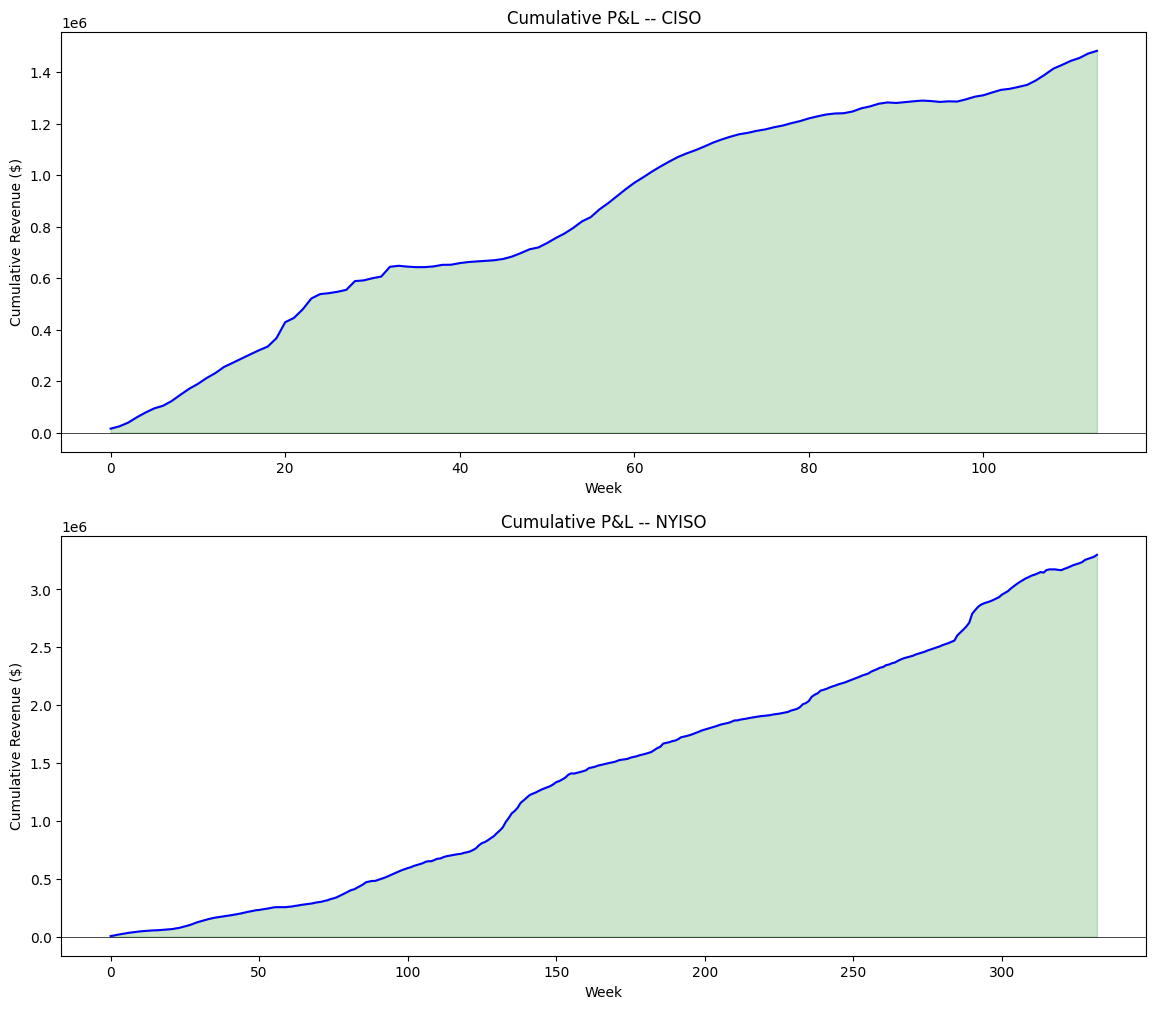

CISO Max drawdown: $-5,310
NYISO Max drawdown: $-6,672


In [24]:
#cum p/l and max dd
fig, axes = plt.subplots(2,1,figsize=(14,12))

ciso_cumulative = np.cumsum(ciso_revenues)
axes[0].plot(ciso_cumulative, color='blue')
axes[0].fill_between(range(len(ciso_cumulative)), ciso_cumulative, 
                     where=ciso_cumulative >= 0, color='green', alpha=0.2)
axes[0].fill_between(range(len(ciso_cumulative)), ciso_cumulative, 
                     where=ciso_cumulative < 0, color='red', alpha=0.2)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Cumulative Revenue ($)")
axes[0].set_title("Cumulative P&L -- CISO")

nyiso_cumulative = np.cumsum(nyiso_revenues)
axes[1].plot(nyiso_cumulative, color='blue')
axes[1].fill_between(range(len(nyiso_cumulative)), nyiso_cumulative, 
                     where=nyiso_cumulative >= 0, color='green', alpha=0.2)
axes[1].fill_between(range(len(nyiso_cumulative)), nyiso_cumulative, 
                     where=nyiso_cumulative < 0, color='red', alpha=0.2)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Cumulative Revenue ($)")
axes[1].set_title("Cumulative P&L -- NYISO")

plt.show()

ciso_peak = np.maximum.accumulate(ciso_cumulative)
ciso_drawdown = ciso_cumulative - ciso_peak
print(f"CISO Max drawdown: ${ciso_drawdown.min():,.0f}")

nyiso_peak = np.maximum.accumulate(nyiso_cumulative)
nyiso_drawdown = nyiso_cumulative - nyiso_peak
print(f"NYISO Max drawdown: ${nyiso_drawdown.min():,.0f}")

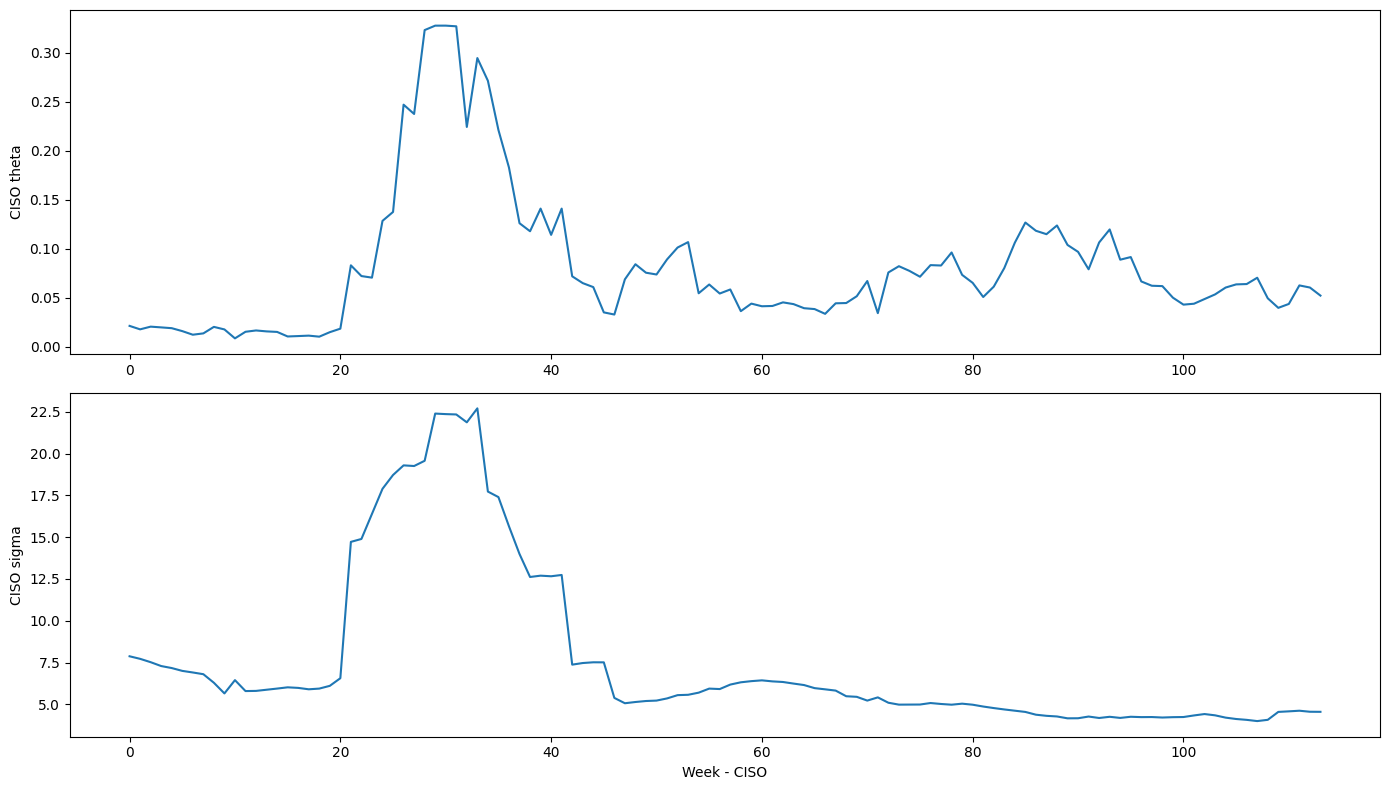

In [13]:
#theta, sig vs time - ciso
ciso_thetas = [r["theta"] for r in ciso_results]
ciso_sigmas = [r["sigma"] for r in ciso_results]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(ciso_thetas)
axes[0].set_ylabel("CISO theta")
axes[1].plot(ciso_sigmas)
axes[1].set_ylabel("CISO sigma")
plt.xlabel("Week - CISO")
plt.tight_layout()
plt.show()

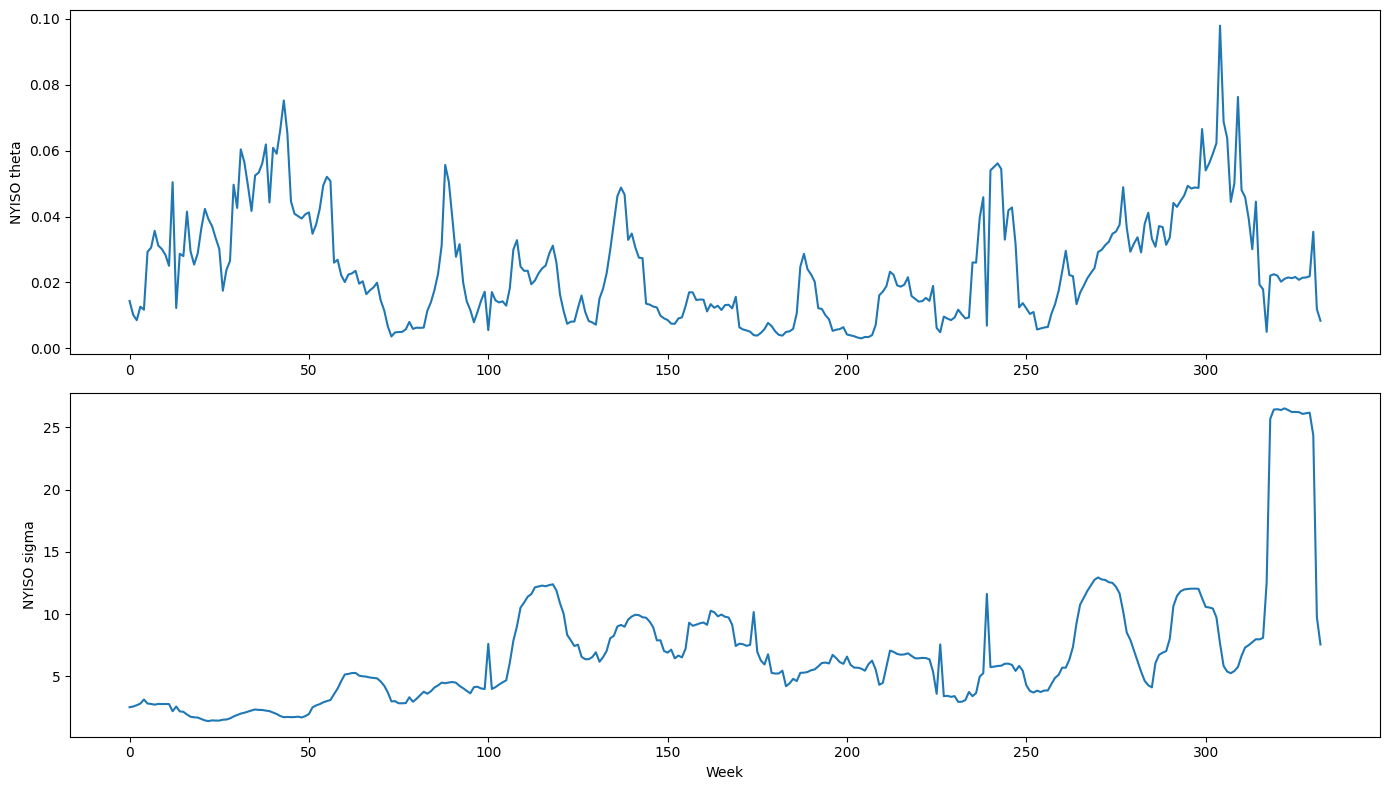

In [26]:
#theta, sig vs time - nyiso
nyiso_thetas = [r["theta"] for r in nyiso_results]
nyiso_sigmas = [r["sigma"] for r in nyiso_results]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(nyiso_thetas)
axes[0].set_ylabel("NYISO theta")
axes[1].plot(nyiso_sigmas)
axes[1].set_ylabel("NYISO sigma")
plt.xlabel("Week")
plt.tight_layout()
plt.show()

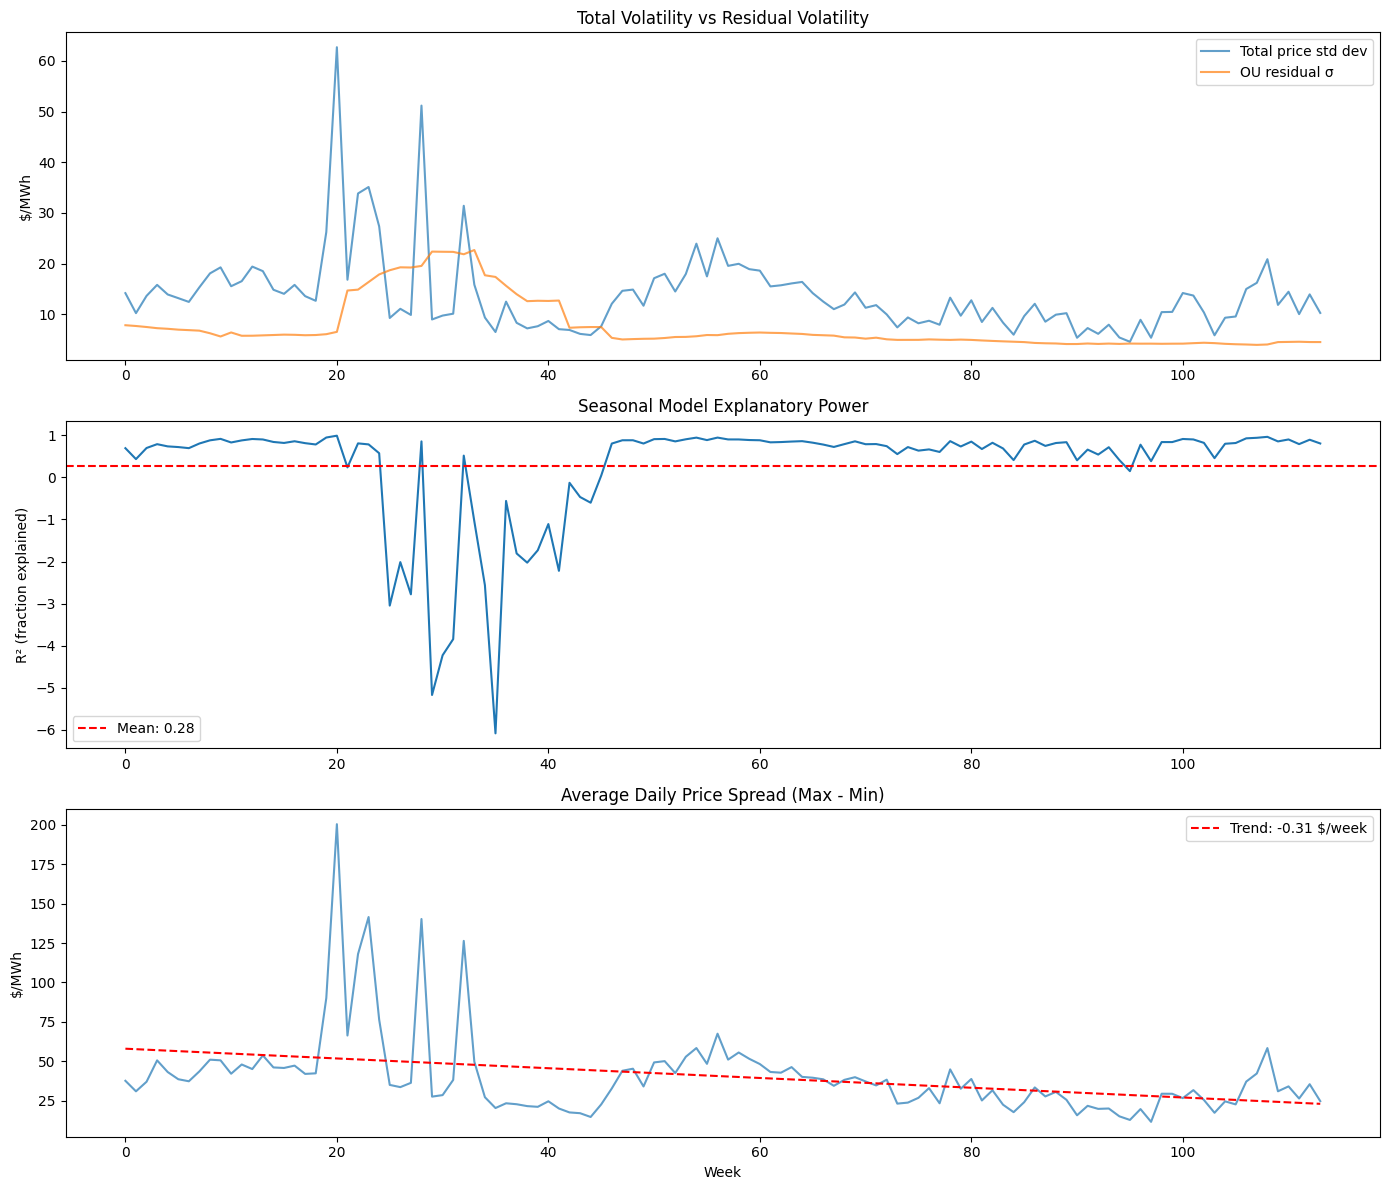

In [28]:
#var decomp CISO
eval_window = 24 * 7

diagnostics = []

for r in ciso_results:
    start = r["eval_start"]
    week_prices = ciso["price_usd_mwh"].values[start:start + eval_window]
    
    total_vol = np.std(week_prices)
    
    daily_spreads = []
    for d in range(7):
        day_prices = week_prices[d * 24:(d + 1) * 24]
        daily_spreads.append(day_prices.max() - day_prices.min())
    avg_spread = np.mean(daily_spreads)
    
    r["total_vol"] = total_vol
    r["avg_spread"] = avg_spread

weeks = range(len(ciso_results))
total_vols = [r["total_vol"] for r in ciso_results]
avg_spreads = [r["avg_spread"] for r in ciso_results]
sigmas = [r["sigma"] for r in ciso_results]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Raw price vol vs residual sigma over time
axes[0].plot(weeks, total_vols, label="Total price std dev", alpha=0.7)
axes[0].plot(weeks, sigmas, label="OU residual σ", alpha=0.7)
axes[0].set_ylabel("$/MWh")
axes[0].set_title("Total Volatility vs Residual Volatility")
axes[0].legend()

# 2. Fraction of variance explained by seasonal model
variance_explained = [1 - (s**2 / tv**2) if tv > 0 else 0 
                      for s, tv in zip(sigmas, total_vols)]
axes[1].plot(weeks, variance_explained)
axes[1].set_ylabel("R² (fraction explained)")
axes[1].set_title("Seasonal Model Explanatory Power")
axes[1].axhline(y=np.mean(variance_explained), color='r', 
                linestyle='--', label=f"Mean: {np.mean(variance_explained):.2f}")
axes[1].legend()

# 3. Average daily spread over time
axes[2].plot(weeks, avg_spreads, alpha=0.7)
z = np.polyfit(weeks, avg_spreads, 1)
axes[2].plot(weeks, np.polyval(z, list(weeks)), 'r--', 
             label=f"Trend: {z[0]:+.2f} $/week")
axes[2].set_ylabel("$/MWh")
axes[2].set_xlabel("Week")
axes[2].set_title("Average Daily Price Spread (Max - Min)")
axes[2].legend()

plt.tight_layout()
plt.show()

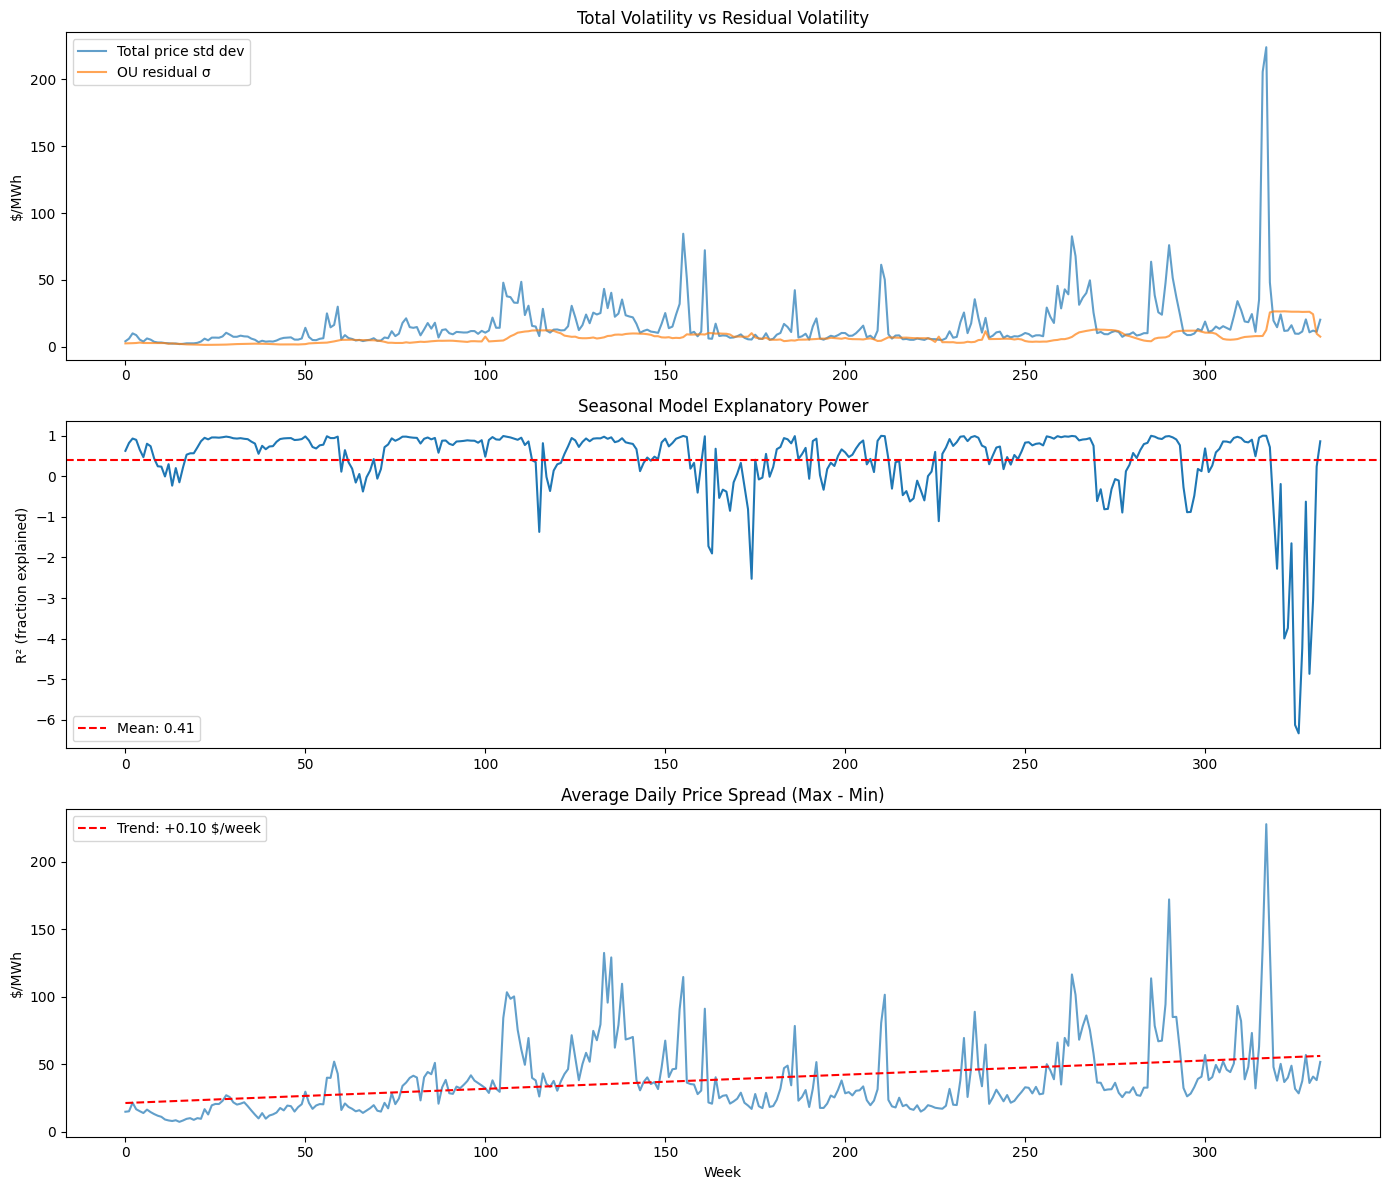

In [30]:
#var decomp NYISO

eval_window = 24 * 7

diagnostics = []

for r in nyiso_results:
    start = r["eval_start"]
    week_prices = nyiso["price_usd_mwh"].values[start:start + eval_window]
    
    total_vol = np.std(week_prices)
    
    daily_spreads = []
    for d in range(7):
        day_prices = week_prices[d * 24:(d + 1) * 24]
        daily_spreads.append(day_prices.max() - day_prices.min())
    avg_spread = np.mean(daily_spreads)
    
    r["total_vol"] = total_vol
    r["avg_spread"] = avg_spread

weeks = range(len(nyiso_results))
total_vols = [r["total_vol"] for r in nyiso_results]
avg_spreads = [r["avg_spread"] for r in nyiso_results]
sigmas = [r["sigma"] for r in nyiso_results]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Raw price vol vs residual sigma over time
axes[0].plot(weeks, total_vols, label="Total price std dev", alpha=0.7)
axes[0].plot(weeks, sigmas, label="OU residual σ", alpha=0.7)
axes[0].set_ylabel("$/MWh")
axes[0].set_title("Total Volatility vs Residual Volatility")
axes[0].legend()

# 2. Fraction of variance explained by seasonal model
variance_explained = [1 - (s**2 / tv**2) if tv > 0 else 0 
                      for s, tv in zip(sigmas, total_vols)]
axes[1].plot(weeks, variance_explained)
axes[1].set_ylabel("R² (fraction explained)")
axes[1].set_title("Seasonal Model Explanatory Power")
axes[1].axhline(y=np.mean(variance_explained), color='r', 
                linestyle='--', label=f"Mean: {np.mean(variance_explained):.2f}")
axes[1].legend()

# 3. Average daily spread over time
axes[2].plot(weeks, avg_spreads, alpha=0.7)
z = np.polyfit(weeks, avg_spreads, 1)
axes[2].plot(weeks, np.polyval(z, list(weeks)), 'r--', 
             label=f"Trend: {z[0]:+.2f} $/week")
axes[2].set_ylabel("$/MWh")
axes[2].set_xlabel("Week")
axes[2].set_title("Average Daily Price Spread (Max - Min)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [31]:
#perf foresight comp - CISO
eval_window = 24 * 7
train_window = 24 * 365
soc_grid = np.linspace(0, 100, 41)
params = {"u_max": 25, "eta": 0.85, "S_max": 100, "S_0": 0, "dt": 1}


pf_results = []

for r in ciso_results:
    start = r["eval_start"]
    eval_data = ciso.iloc[start:start + eval_window].copy()  
    actual_prices = eval_data["price_usd_mwh"].values

    train_end = start
    train_data = ciso.iloc[train_end - train_window:train_end]
    params["q"] = train_data["price_usd_mwh"].mean()
    
    pf_rev = perfect_foresight(actual_prices, soc_grid, params)
    pf_results.append(pf_rev)

opt_revs = [r["revenue"] for r in ciso_results]

capture = [o / p if p > 0 else 0 for o, p in zip(opt_revs, pf_results)]
mean_of_ratios = np.mean(capture)
ratio_of_means = np.sum(opt_revs) / np.sum(pf_results)

print("CISO:")
print(f"Value capture (mean of ratios): {mean_of_ratios:.1%}")
print(f"Value capture (ratio of means): {ratio_of_means:.1%}")
print(f"Median value capture: {np.median(capture):.1%}")
print(f"Mean optimal: ${np.mean(opt_revs):,.0f}")
print(f"Mean perfect foresight: ${np.mean(pf_results):,.0f}")

CISO:
Value capture (mean of ratios): 70.0%
Value capture (ratio of means): 79.8%
Median value capture: 80.6%
Mean optimal: $13,014
Mean perfect foresight: $16,299


In [32]:
#perf foresight comp -- NYISO
eval_window = 24 * 7
train_window = 24 * 365
soc_grid = np.linspace(0, 100, 41)
params = {"u_max": 25, "eta": 0.85, "S_max": 100, "S_0": 0, "dt": 1}


pf_results = []

for r in nyiso_results:
    start = r["eval_start"]
    eval_data = nyiso.iloc[start:start + eval_window].copy() 
    actual_prices = eval_data["price_usd_mwh"].values

    train_end = start
    train_data = nyiso.iloc[train_end - train_window:train_end]
    params["q"] = train_data["price_usd_mwh"].mean()
    
    pf_rev = perfect_foresight(actual_prices, soc_grid, params)
    pf_results.append(pf_rev)

opt_revs = [r["revenue"] for r in nyiso_results]

capture = [o / p if p > 0 else 0 for o, p in zip(opt_revs, pf_results)]
mean_of_ratios = np.mean(capture)
ratio_of_means = np.sum(opt_revs) / np.sum(pf_results)

print("NYISO:")
print(f"Value capture (mean of ratios): {mean_of_ratios:.1%}")
print(f"Value capture (ratio of means): {ratio_of_means:.1%}")
print(f"Median value capture: {np.median(capture):.1%}")
print(f"Mean optimal: ${np.mean(opt_revs):,.0f}")
print(f"Mean perfect foresight: ${np.mean(pf_results):,.0f}")

NYISO:
Value capture (mean of ratios): 86.7%
Value capture (ratio of means): 71.0%
Median value capture: 88.6%
Mean optimal: $9,907
Mean perfect foresight: $13,951
